In [7]:
import getpass
import os
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_community.document_loaders import WebBaseLoader
from langchain_community.vectorstores import Chroma
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_core.prompts import ChatPromptTemplate
from langchain import hub
from langchain_core.output_parsers import StrOutputParser
from langchain_community.tools.tavily_search import TavilySearchResults
from langgraph.graph import StateGraph,START, END
from typing import List, TypedDict
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.errors import GraphRecursionError

In [8]:
# Set environment variables for API keys
def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")


_set_env("OPENAI_API_KEY")
_set_env("TAVILY_API_KEY")

# Initialize embeddings and vectorstore
embd = OpenAIEmbeddings()


In [9]:
from langchain.retrievers.self_query.base import SelfQueryRetriever
from langchain.chains.query_constructor.base import AttributeInfo

# Step 1: Define a paragraph
paragraph = "The quick brown fox jumps over the lazy dog. This is a common English sentence used for typing practice."

# Step 2: Generate embeddings and store in Chroma DB
text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=0)
texts = text_splitter.create_documents([paragraph])

# Initialize Chroma DB
vectorstore = Chroma.from_documents(texts, embd, collection_name="paragraph_collection")

# Step 3: Define metadata and self-query retriever
metadata_field_info = [
    AttributeInfo(
        name="source",
        description="The source of the paragraph",
        type="string",
    )
]
document_content_description = "A paragraph of text"

retriever = SelfQueryRetriever.from_llm(
    ChatOpenAI(temperature=0, model="gpt-3.5-turbo"),
    vectorstore,
    document_content_description,
    metadata_field_info,
    verbose=True
)

# Step 4: Retrieve based on a query
query = "What is the sentence about?"
docs = retriever.get_relevant_documents(query)

# Step 5: Answer using GPT-3.5 Turbo
if docs:
    llm = ChatOpenAI(temperature=0, model="gpt-3.5-turbo")
    prompt = ChatPromptTemplate.from_template("Based on the following context, answer the question:\n\nContext: {context}\n\nQuestion: {question}")
    chain = prompt | llm | StrOutputParser()
    context = "\n".join([doc.page_content for doc in docs])
    response = chain.invoke({"context": context, "question": query})
    print("Answer:", response)
else:
    print("No answer")

Number of requested results 4 is greater than number of elements in index 2, updating n_results = 2


Answer: The sentence is about a quick brown fox jumping over a lazy dog.


In [ ]:
from langgraph.graph import StateGraph, END
from typing import TypedDict, List, Optional

# Define the state of the graph
class GraphState(TypedDict):
    query: str  # The user's query
    docs: Optional[List]  # Retrieved documents
    response: Optional[str]  # Final response
    web_search_count: int  # Count of web searches

# Node: Accept user query
def get_query(state: GraphState):
    print("Please enter your query:")
    query = input()  # Simulate user input
    return {"query": query,"web_search_count":0}

# Node: Retrieve documents using Self-Query Retriever
def retrieve_documents(state: GraphState):
    query = state["query"]
    retriever = SelfQueryRetriever.from_llm(
        ChatOpenAI(temperature=0, model="gpt-3.5-turbo"),
        vectorstore,  # Use the pre-initialized Chroma vectorstore
        document_content_description="A paragraph of text",
        metadata_field_info=[
            AttributeInfo(
                name="source",
                description="The source of the paragraph",
                type="string",
            )
        ],
        verbose=True
    )  
    docs = retriever.get_relevant_documents(query)
    return {"docs": docs}

# Node: Check if documents are found
def check_context(state: GraphState):
    if state["docs"]:  # If documents are found
        return "yes"  # Proceed to generate answer
    else:  # If no documents are found
        return "no"  # End the workflow

def web_search(state: GraphState):
    """Perform a web search using the Tavily API."""
    #print("---WEB SEARCH---")
    if state["web_search_count"] >= 3:  # Set recursion limit to 3
        raise GraphRecursionError("Recursion limit exceeded: Maximum web search attempts reached.")
    question = state["question"]
    web_search_tool = TavilySearchResults(k=3)
    docs = web_search_tool.invoke({"query": question})
    web_results = "\n".join([d["content"] for d in docs])
    return {"documents": [web_results], "question": question,"web_search_count": state["web_search_count"] + 1}

# Node: Generate answer using LLM
def generate_answer(state: GraphState):
    context = "\n".join([doc.page_content for doc in state["docs"]])
    response = chain.invoke({"context": context, "question": state["query"]})
    return {"response": response}


# Step 2: Initialize Chroma DB (assume documents are already stored)
embd = OpenAIEmbeddings()  # Embedding model
vectorstore = Chroma(collection_name="paragraph_collection", embedding_function=embd)

# Step 3: Define the graph
workflow = StateGraph(GraphState)

# Add nodes to the graph
workflow.add_node("get_query", get_query)
workflow.add_node("retriever",retrieve_documents)
workflow.add_node("check_context", check_context)
workflow.add_node("generate_answer", generate_answer)
workflow.add_node("web_search", web_search)

# Define edges (transitions between nodes)
workflow.add_edge(START,"get_query") 
workflow.add_edge("get_query","retriever")
workflow.add_edge("retriever","check_context")
workflow.add_conditional_edges(
    "check_context",  # Source node
    lambda state: "generate_answer" if state["docs"] else END,  # Conditional function
    {"yes": "generate_answer", 
     "no":"web_search"},  # Possible destinations
)
workflow.add_edge("generate_answer",END)
workflow.add_edge("web_search","check_context")
# Set entry point
workflow.set_entry_point("get_query")

# Compile the graph
app = workflow.compile()

In [11]:
print(app)

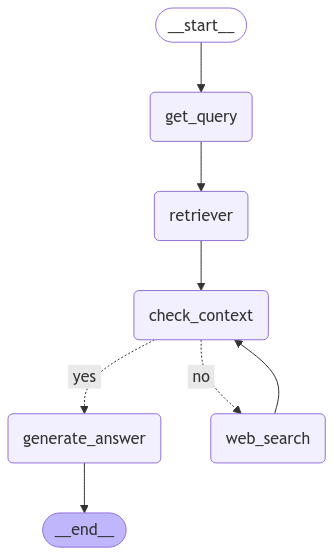

In [12]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [ ]:
# Step 4: Run the workflow
initial_state = {}  # Initial state is empty
try:
    result = app.invoke(initial_state)
    print("Final Response:", result.get("response", "No response generated."))
except GraphRecursionError as e:
    print(f"Workflow terminated: {e}")

In [15]:
import openai
import numpy as np
from elasticsearch import Elasticsearch
from langchain.embeddings import OpenAIEmbeddings
from langchain.vectorstores import ElasticsearchStore
from langchain.retrievers import SelfQueryRetriever
from langchain.chat_models import ChatOpenAI
from langchain.prompts import PromptTemplate
from langchain.chains.query_constructor.base import AttributeInfo
from unstructured.partition.pdf import partition_pdf

In [ ]:

# Class to parse PDF
class DocumentParser:
    def __init__(self, file_path, infer_table_structure=True):
        self.file_path = file_path
        self.infer_table_structure = infer_table_structure

    def pdf_to_raw_elements(self):
        raw_pdf_elements = partition_pdf(
            filename=self.file_path,
            extract_images_in_pdf=False,
            infer_table_structure=self.infer_table_structure,
            chunking_strategy="by_title",
            max_characters=4000,
            new_after_n_chars=3800,
            include_metadata=True,
        )
        return raw_pdf_elements


# Class to handle embeddings generation
class EmbeddingGenerator:
    def __init__(self, model="text-embedding-ada-002"):
        self.model = model

    def get_embeddings(self, texts):
        embeddings = []
        for text in texts:
            response = openai.Embedding.create(input=text, model=self.model)
            embeddings.append(response['data'][0]['embedding'])
        return embeddings


# Class for Elasticsearch indexing and querying
class ElasticsearchHandler:
    def __init__(self, es_connection, index_name="pdf_embeddings"):
        self.es = es_connection
        self.index_name = index_name
        self.setup_index()

    def setup_index(self):
        if not self.es.indices.exists(index=self.index_name):
            self.es.indices.create(
                index=self.index_name,
                body={
                    "mappings": {
                        "properties": {
                            "chunk_id": {"type": "keyword"},
                            "text": {"type": "text"},
                            "embedding": {"type": "dense_vector", "dims": 1024},  # Corrected dimensions
                            "metadata": {"type": "object"}
                        }
                    }
                },
            )

    def store_embeddings(self, embeddings, texts, metadata_list):
        for idx, (embedding, text, metadata) in enumerate(zip(embeddings, texts, metadata_list)):
            doc = {
                "chunk_id": f"chunk_{idx}",
                "text": text,
                "embedding": embedding,
                "metadata": metadata
            }
            self.es.index(index=self.index_name, id=f"chunk_{idx}", document=doc)

    